In [34]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import seaborn as sns

sns.set_theme()
sns.set_style("ticks")
sns.set_context("talk")
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [2]:
def parse_qmc_filename(fname):
    """
    Parse QMC filename and return metadata dictionary.

    Expected format:
    K_square_1D_16L_8N_PBC_0.000U_8.00beta_200bins10000_seed2001.dat
    """

    pattern = re.compile(
        r"(K|V)_"                 # energy type
        r"(\w+)_"                 # lattice type
        r"(1D|2D)_"               # dimension
        r"(\d+)L_"                # L
        r"(\d+)N_"                # N
        r"(\w+)_"                 # boundary condition
        r"([0-9.]+)U_"            # interaction
        r"([0-9.]+)beta_"         # beta
        r"(\d+)bins\d+_"          # bins
        r"seed(\d+)\.dat"
    )

    m = pattern.match(fname)

    if not m:
        return None

    return {
        "kind": m.group(1),
        "lattice": m.group(2),
        "dim": m.group(3),
        "L": int(m.group(4)),
        "N": int(m.group(5)),
        "bc": m.group(6),
        "U": float(m.group(7)),
        "beta": float(m.group(8)),
        "bins": int(m.group(9)),
        "seed": int(m.group(10)),
    }

# Functions for loading in qmc, vmc, and exact data

In [3]:
def load_qmc_directory(data_dir):
    """
    Load all QMC energy files in a directory.

    Returns dataframe indexed by (U, beta, L, N).
    """

    energy_data = {}

    for fname in os.listdir(data_dir):

        meta = parse_qmc_filename(fname)

        if meta is None:
            continue

        key = (meta["U"], meta["beta"], meta["L"], meta["N"])

        fpath = os.path.join(data_dir, fname)

        df = pd.read_csv(fpath, delim_whitespace=True, header=None)

        mean = df[0].mean()
        std = df[0].std()

        if key not in energy_data:
            energy_data[key] = {}

        energy_data[key][f"{meta['kind']}_mean"] = mean
        energy_data[key][f"{meta['kind']}_std"] = std

    if not energy_data:
        raise ValueError(f"No QMC files found in {data_dir}")

    df_energy = pd.DataFrame.from_dict(energy_data, orient="index")

    df_energy.index = pd.MultiIndex.from_tuples(
        df_energy.index,
        names=["U", "beta", "L", "N"]
    )

    df_energy.sort_index(inplace=True)

    if "K_mean" in df_energy and "V_mean" in df_energy:
        df_energy["Total_mean"] = df_energy["K_mean"] + df_energy["V_mean"]
        df_energy["Total_std"] = (df_energy["K_std"]**2 + df_energy["V_std"]**2)**0.5

    return df_energy

In [4]:
def build_benchmark_dataframe(L, N, base_dir="../data", dim="1D", type="C"):

    tag = f"L{L}_N{N}"

    gutzwiller_path = f"{base_dir}/{type}/{dim}/{tag}/VMC_results.dat"
    gutzwiller_parts_path = f"{base_dir}/{type}/{dim}/{tag}/VMC_energy_parts.dat"

    jastrow_path = f"{base_dir}/{type}/{dim}/{tag}/jastrow/VMC_results.dat"
    jastrow_parts_path = f"{base_dir}/{type}/{dim}/{tag}/jastrow/VMC_energy_parts.dat"

    qmc_dir = f"{base_dir}/QMC/{dim}_{tag}"
    exact_path = f"{base_dir}/exact/{dim}_{tag}.dat"

    # -----------------------
    # Gutzwiller total energy
    # -----------------------

    df_gutzwiller = pd.read_csv(
        gutzwiller_path,
        delim_whitespace=True,
        comment="#",
        names=["U", "kappa", "E_gutzwiller", "sem_gutzwiller", "mu"]
    )

    df_gutzwiller = df_gutzwiller[["U", "E_gutzwiller", "sem_gutzwiller"]]

    # -----------------------
    # Gutzwiller components
    # -----------------------

    gutzwiller_parts = np.loadtxt(gutzwiller_parts_path, comments="#")

    df_gutzwiller_parts = pd.DataFrame({
        "U": gutzwiller_parts[:,0],
        "T_gutzwiller": gutzwiller_parts[:,1],
        "T_gutzwiller_std": gutzwiller_parts[:,2],
        "V_gutzwiller": gutzwiller_parts[:,3],
        "V_gutzwiller_std": gutzwiller_parts[:,4],
    })

    # -----------------------
    # Jastrow total energy
    # -----------------------

    if os.path.exists(jastrow_path):

        df_jastrow = pd.read_csv(
            jastrow_path,
            delim_whitespace=True,
            comment="#",
            names=["U","E_jastrow","sem_jastrow"]
        )

    else:

        df_jastrow = pd.DataFrame(columns=["U","E_jastrow","sem_jastrow"])


    # -----------------------
    # Jastrow components
    # -----------------------

    if os.path.exists(jastrow_parts_path):

        parts = np.loadtxt(jastrow_parts_path, comments="#")

        df_jastrow_parts = pd.DataFrame({
            "U": parts[:,0],
            "T_jastrow": parts[:,1],
            "T_jastrow_std": parts[:,2],
            "V_jastrow": parts[:,3],
            "V_jastrow_std": parts[:,4],
        })

    else:

        df_jastrow_parts = pd.DataFrame(columns=[
            "U","T_jastrow","T_jastrow_std","V_jastrow","V_jastrow_std"
        ])

    # -----------------------
    # Exact data
    # -----------------------

    df_exact = pd.DataFrame(columns=["U","E_exact","T_exact","V_exact"])

    if dim == "1D" and os.path.exists(exact_path):

        exact = np.loadtxt(exact_path)

        df_exact = pd.DataFrame({
            "U": exact[:,0],
            "E_exact": exact[:,1],
            "T_exact": exact[:,2],
            "V_exact": exact[:,3]
        })

    # -----------------------
    # QMC data
    # -----------------------

    qmc_df = load_qmc_directory(qmc_dir)

    qmc_data = (
        qmc_df
        .xs((L, N), level=("L","N"))
        .reset_index()
    )

    qmc_data = qmc_data[[
        "U",
        "K_mean",
        "K_std",
        "V_mean",
        "V_std",
        "Total_mean",
        "Total_std"
    ]]

    qmc_data.rename(columns={
        "K_mean":"T_qmc",
        "K_std":"T_qmc_std",
        "V_mean":"V_qmc",
        "V_std":"V_qmc_std",
        "Total_mean":"E_qmc",
        "Total_std":"sem_qmc"
    }, inplace=True)

    # -----------------------
    # Merge everything
    # -----------------------

    df = df_gutzwiller.merge(df_gutzwiller_parts, on="U", how="left")
    df = df.merge(df_jastrow, on="U", how="left")
    df = df.merge(df_jastrow_parts, on="U", how="left")
    df = df.merge(df_exact, on="U", how="left")
    df = df.merge(qmc_data, on="U", how="left")

    df.sort_values("U", inplace=True)

    return df

# Functions for plotting total energy and energy components (kinetic and potential) separately

In [31]:
def plot_energy_comparison(df,
                           title="",
                           save_path=None,
                           plot_gutzwiller=True,
                           plot_jastrow=True,
                           plot_qmc=True,
                           plot_exact=True):

    plt.figure()

    if plot_gutzwiller and "E_gutzwiller" in df.columns:
        plt.errorbar(df["U"], df["E_gutzwiller"],
                     yerr=df.get("sem_gutzwiller"),
                     label="Gutzwiller", c='r', fmt='o', capsize=3)

    if plot_jastrow and "E_jastrow" in df.columns:
        plt.errorbar(df["U"], df["E_jastrow"],
                     yerr=df.get("sem_jastrow"),
                     label="Jastrow", c='g', fmt='o', capsize=3)

    if plot_qmc and "E_qmc" in df.columns:
        plt.errorbar(df["U"], df["E_qmc"],
                     yerr=df.get("sem_qmc"),
                     label="QMC", c='b', fmt='o', capsize=3)

    if plot_exact and "E_exact" in df.columns:
        plt.plot(df["U"], df["E_exact"],
                 label="Exact", linestyle='--', c='k')

    plt.xlabel(r"$U/t$")
    plt.ylabel("Energy")
    plt.legend(loc="best", fontsize=13)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

In [32]:
def plot_energy_components(df,
                           title_prefix="",
                           save_path=None,
                           plot_gutzwiller=True,
                           plot_jastrow=True,
                           plot_qmc=True,
                           plot_exact=True):

    fig, axes = plt.subplots(1,2, figsize=(10,4), constrained_layout=True)

    # ----------------
    # kinetic
    # ----------------

    if plot_gutzwiller and "T_gutzwiller" in df.columns:
        axes[0].errorbar(df["U"], df["T_gutzwiller"],
                         yerr=df.get("T_gutzwiller_std"),
                         fmt='o', c='r',
                         label="Gutzwiller")

    if plot_jastrow and "T_jastrow" in df.columns:
        axes[0].errorbar(df["U"], df["T_jastrow"],
                         yerr=df.get("T_jastrow_std"),
                         fmt='o', c='g',
                         label="Jastrow")

    if plot_qmc and "T_qmc" in df.columns:
        axes[0].errorbar(df["U"], df["T_qmc"],
                         yerr=df.get("T_qmc_std"),
                         fmt='o', c='b',
                         label="QMC")

    if plot_exact and "T_exact" in df.columns:
        axes[0].plot(df["U"], df["T_exact"],
                     linestyle="--", c='k',
                     label="Exact")

    axes[0].set_title("Kinetic")
    axes[0].set_ylabel("Energy")

    # ----------------
    # potential
    # ----------------

    if plot_gutzwiller and "V_gutzwiller" in df.columns:
        axes[1].errorbar(df["U"], df["V_gutzwiller"],
                         yerr=df.get("V_gutzwiller_std"),
                         fmt='o', c='r',
                         label="Gutzwiller")

    if plot_jastrow and "V_jastrow" in df.columns:
        axes[1].errorbar(df["U"], df["V_jastrow"],
                         yerr=df.get("V_jastrow_std"),
                         fmt='o', c='g',
                         label="Jastrow")

    if plot_qmc and "V_qmc" in df.columns:
        axes[1].errorbar(df["U"], df["V_qmc"],
                         yerr=df.get("V_qmc_std"),
                         fmt='o', c='b',
                         label="QMC")

    if plot_exact and "V_exact" in df.columns:
        axes[1].plot(df["U"], df["V_exact"],
                     linestyle="--", c='k',
                     label="Exact")

    axes[1].set_title("Potential")

    for ax in axes:
        ax.set_xlabel(r"$U/t$")

    axes[0].legend(loc="best", fontsize=13)

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

# Function that automatically calls functions for loading in data and plotting them depending on system parameters (can take more than one (L,N) pairs at a time)

In [7]:
def process_benchmark_setups(
        pairs,
        base_dir="../data",
        dim="1D",
        type="C",
        save_dir="./figures",
        plot=True,
        plot_gutzwiller=True,
        plot_jastrow=True,
        plot_qmc=True,
        plot_exact=True):

    import os

    os.makedirs(save_dir, exist_ok=True)

    for L, N in pairs:

        tag = f"L{L}_N{N}"

        plot_dir = f"{save_dir}/{dim}/{tag}/{type}"
        os.makedirs(plot_dir, exist_ok=True)

        try:

            df = build_benchmark_dataframe(
                L,
                N,
                base_dir,
                dim,
                type
            )

            comparison_plot = f"{plot_dir}/comparison.pdf"
            energy_parts_plot = f"{plot_dir}/T_V.pdf"

            plot_energy_comparison(
                df,
                title=f"{dim}, L={L}, N={N}",
                save_path=None if plot else comparison_plot,
                plot_gutzwiller=plot_gutzwiller,
                plot_jastrow=plot_jastrow,
                plot_qmc=plot_qmc,
                plot_exact=plot_exact
            )

            plot_energy_components(
                df,
                title_prefix=f"{dim}, L={L}, N={N}",
                save_path=None if plot else energy_parts_plot,
                plot_gutzwiller=plot_gutzwiller,
                plot_jastrow=plot_jastrow,
                plot_qmc=plot_qmc,
                plot_exact=plot_exact
            )

        except Exception as e:

            print(f"❌ Failed for {dim} L={L} N={N}: {e}")

## QMC Runs

julia pigsfli.jl --geometry "square" -D 1 -L 16 -N 8 -l 2 -U [0.0-7.0] --beta 8.0 --bin-size 10000 --bins-wanted 400 --seed 2001 --boundary "pbc" --trial-state "gutzwiller" --kappa [INSERT VMC VALUE]

Note: could not get U = 8.0, 9.0, 10.0 to complete particle number tuning for beta = 12.0

julia pigsfli.jl --geometry "square" -D 1 -L 12 -N 12 -l 2 -U [8.0-10.0] --beta 8.0 --bin-size 100000 --bins-wanted 200 --seed 2001 --boundary "pbc" --trial-state "gutzwiller" --kappa [INSERT VMC VALUE]

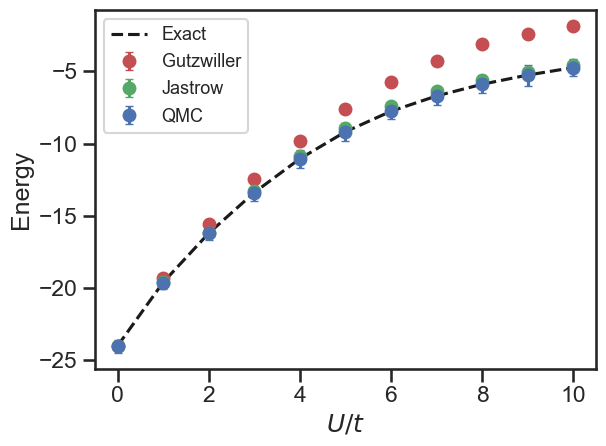

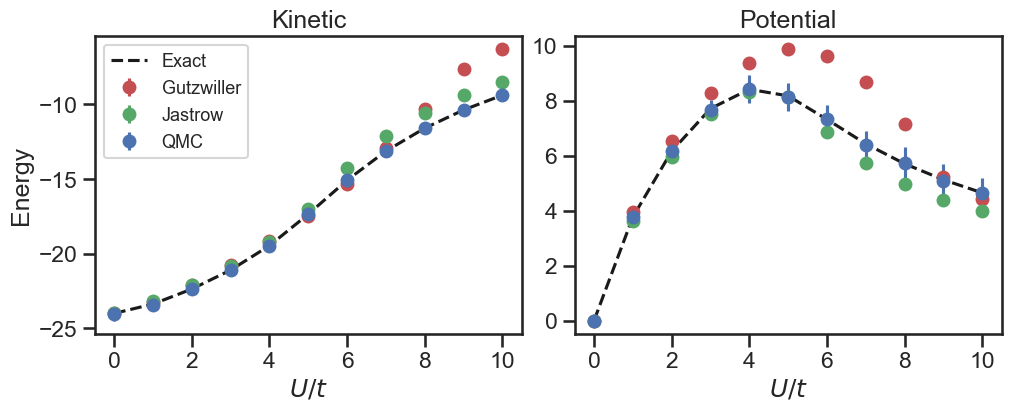

In [35]:
# Define list of (L, N) pairs
benchmark_pairs = [(12, 12)]

# Run processing for all pairs
process_benchmark_setups(benchmark_pairs, base_dir="../data", type="C", save_dir="./figures/", plot=True, plot_gutzwiller=True, plot_qmc=True)

# By-hand exact calculations for grand canonical Hamiltonian expectation value with Gutzwiller wavefunction

In [9]:
import numpy as np
import math
from scipy.optimize import minimize_scalar

U = 10.0
t = 1.0
mu = 4.2
n_max = 8  # match your VMC truncation

def f_vec(kappa, n_max):
    n = np.arange(n_max + 1, dtype=float)
    # unnormalized amplitudes
    f = np.exp(-0.5 * kappa * n**2) / np.sqrt([math.factorial(int(m)) for m in n])
    # normalize in |f|^2
    f = f / np.sqrt(np.sum(f**2))
    return f

def energy_2site_gutz(kappa):
    f = f_vec(kappa, n_max)
    n = np.arange(n_max + 1, dtype=float)

    # single-site moments
    nbar = np.sum(n * f**2)
    nnm1 = np.sum(n * (n - 1) * f**2)

    # <b> on one site
    bbar = 0.0
    for m in range(n_max):
        bbar += math.sqrt(m + 1) * f[m] * f[m + 1]

    # 2-site energy with one bond
    H_U  = U * nnm1                  # 2 sites: 2*(U/2*<n(n-1)>) = U*<n(n-1)>
    H_mu = -2 * mu * nbar
    H_K  = -2 * t * (bbar**2)

    return H_K + H_U + H_mu

res = minimize_scalar(energy_2site_gutz, bounds=(1e-8, 10), method="bounded")
print(f"Optimal kappa = {res.x:.12f}")
print(f"Minimum H(kappa) = {energy_2site_gutz(res.x):.12f}")

Optimal kappa = 0.318180148464
Minimum H(kappa) = -3.894310942704


# Total Particle Number Distribution Plot

import glob

files = sorted(glob.glob("/Users/wmallah/Documents/GitHub/BH_Gutzwiller_VMC/VMCBoseHubbard/data/GC/1D/L12_N12/PN_hist_U*.dat"))

for file in files:
    print("FILE:", file)
    data = np.loadtxt(file, comments="#")
    if data.ndim == 1:
        data = data[None, :]  # handle single-line case

    N_vals = data[:, 0]
    counts = data[:, 1]
    counts /= counts.sum()  # Normalize

    U = file.split("U")[-1].split(".dat")[0]
    plt.plot(N_vals, counts, label=f"U={U}")

plt.xlabel("Particle Number N")
plt.ylabel("Probability P(N)")
plt.title("Grand Canonical Particle Number Histogram")
plt.legend()
plt.tight_layout()
plt.show()

# Exact Ground State Energy for 2 Particles on 2 Sites

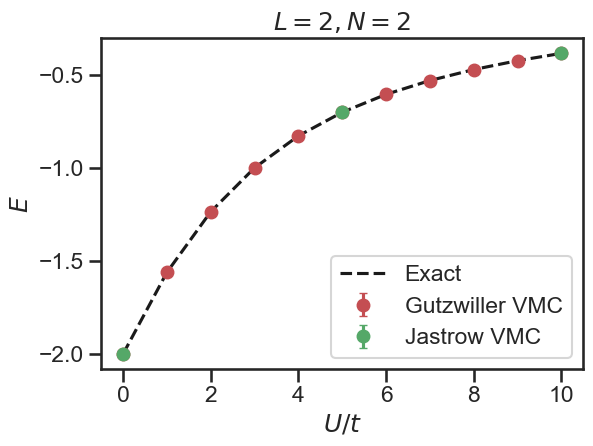

In [10]:
U_vals = np.linspace(0.0, 10.0, 11)
t = 1.0
mu_vals = np.zeros(11)

def E_2_2(U, t, mu):
    return 1/2*(U - np.sqrt(16*t**2 + U**2) - 4*mu)

energies = np.array([])

for index, (U, mu) in enumerate(zip(U_vals, mu_vals)):
    energies = np.append(energies, E_2_2(U, t, mu))

# Load data
Gutzwiller_VMC_data = np.loadtxt(r"../data/C/1D/L2_N2/VMC_results.dat", comments="#")
Gutzwiller_VMC_energies = Gutzwiller_VMC_data[:,2]
Gutzwiller_VMC_errors = Gutzwiller_VMC_data[:, 3]

Jastrow_VMC_data = np.loadtxt(r"../data/C/1D/L2_N2/Jastrow/VMC_results.dat", comments="#")
Jastrow_U_vals = Jastrow_VMC_data[:, 0]
Jastrow_VMC_energies = Jastrow_VMC_data[:,1]
Jastrow_VMC_errors = Jastrow_VMC_data[:, 2]


plt.plot(U_vals, energies, label="Exact", c='k', linestyle="--")
plt.errorbar(U_vals, Gutzwiller_VMC_energies, yerr=Gutzwiller_VMC_errors, label="Gutzwiller VMC", c='r', fmt='o', capsize=3)
plt.errorbar(Jastrow_U_vals, Jastrow_VMC_energies, yerr=Jastrow_VMC_errors, label="Jastrow VMC", c='g', fmt='o', capsize=3)
plt.xlabel(r"$U/t$")
plt.ylabel(r"$E$")
plt.legend(loc="best")
plt.title(r"$L=2, N=2$")
plt.tight_layout()
plt.savefig(r"./figures/2_particles_2sites_comparison.pdf", dpi=600)
plt.show()

# Exact Diagonalization Code Produced by ChatGPT

In [11]:
def ground_state_energy_2bosons_4sites(U, t):
    """
    Exact ground-state energy for 2 bosons on 4 sites (PBC)
    solving:
        E^3 - U E^2 - 16 t^2 E + 8 U t^2 = 0
    Returns the lowest real root.
    """
    # Polynomial coefficients: E^3 + a E^2 + b E + c
    coeffs = [1.0, -U, -16.0 * t**2, 8.0 * U * t**2]

    roots = np.roots(coeffs)

    # Keep real roots only
    real_roots = roots[np.isclose(roots.imag, 0.0, atol=1e-12)].real

    if len(real_roots) == 0:
        raise RuntimeError("No real roots found.")

    return np.min(real_roots)

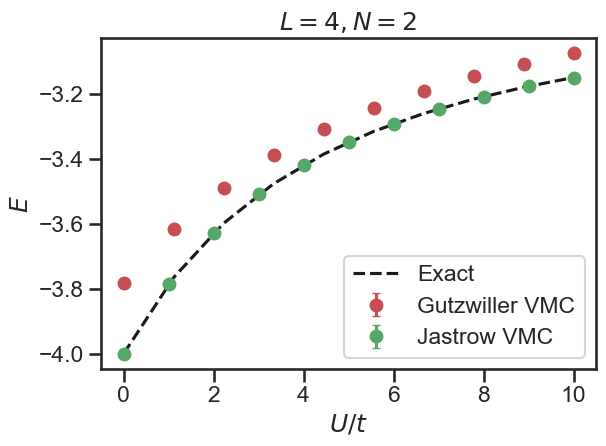

In [12]:
L, N = 4, 2
U_vals = np.linspace(0.0, 10.0, 10)
t = 1.0

energies = np.array([])

for index, U in enumerate(U_vals):
    energies = np.append(energies, ground_state_energy_2bosons_4sites(U, t))

# Load data
Gutzwiller_VMC_data = np.loadtxt(r"../data/C/1D/L4_N2/VMC_results.dat", comments="#")
Gutzwiller_VMC_energies = Gutzwiller_VMC_data[:, 2]
Gutzwiller_VMC_errors = Gutzwiller_VMC_data[:, 3]

Jastrow_VMC_data = np.loadtxt(r"../data/C/1D/L4_N2/Jastrow/VMC_results.dat", comments="#")
Jastrow_U_vals = Jastrow_VMC_data[:, 0]
Jastrow_VMC_energies = Jastrow_VMC_data[:,1]
Jastrow_VMC_errors = Jastrow_VMC_data[:, 2]


plt.plot(U_vals, energies, label="Exact", c='k', linestyle="--")
plt.errorbar(U_vals, Gutzwiller_VMC_energies, yerr=Gutzwiller_VMC_errors, label="Gutzwiller VMC", c='r', fmt='o', capsize=3)
plt.errorbar(Jastrow_U_vals, Jastrow_VMC_energies, yerr=Jastrow_VMC_errors, label="Jastrow VMC", c='g', fmt='o', capsize=3)
plt.xlabel(r"$U/t$")
plt.ylabel(r"$E$")
plt.legend(loc="best")
plt.title(r"$L=4, N=2$")
plt.tight_layout()
plt.savefig(r"./figures/2_particles_4_sites_comparison.pdf", dpi=600)
plt.show()

# Optimal Kappa Versus U/td Plot

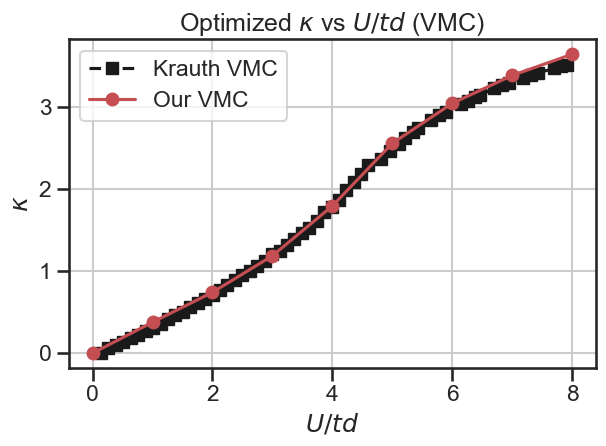

In [13]:
# Load data from Krauth paper
Krauth_data = pd.read_csv("../data/Krauth_kappa_vs_U.csv")
Krauth_data_np = Krauth_data.to_numpy()

Krauth_U = Krauth_data_np[:, 0]
Krauth_kappa = Krauth_data_np[:, 1]

# Load data
# Adjust the filename/path if needed
data = np.loadtxt("../data/C/1D/L16_N16/VMC_results.dat", comments="#")

U = data[:, 0]
kappa = data[:, 1]
energy = data[:, 2]

# Plot κ vs U/t (assuming t = 1)
plt.figure()
plt.plot(Krauth_U, Krauth_kappa, marker='s', linestyle='--', c='k', label="Krauth VMC")
plt.plot(U, kappa, marker='o', linestyle='-', c='r', label="Our VMC")
plt.xlabel(r"$U/td$")
plt.ylabel(r"$\kappa$")
plt.title(r"Optimized $\kappa$ vs $U/td$ (VMC)")
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig("./figures/Krauth_comparison/optimal_kappa_versus_interaction.pdf")
plt.show()

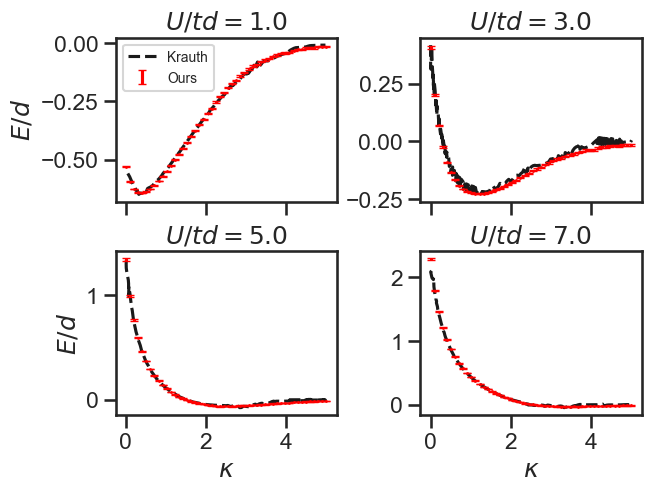

In [14]:
# Krauth U = 1.0 data
Krauth_U1 = pd.read_csv("../data/Krauth_E_vs_kappa_U1.csv")
Krauth_U1_np = Krauth_U1.to_numpy()
Krauth_U1_kappa = Krauth_U1_np[:, 0]
Krauth_U1_E = Krauth_U1_np[:, 1]

# Krauth U = 3.0 data
Krauth_U3 = pd.read_csv("../data/Krauth_E_vs_kappa_U3.csv")
Krauth_U3_np = Krauth_U3.to_numpy()
Krauth_U3_kappa = Krauth_U3_np[:, 0]
Krauth_U3_E = Krauth_U3_np[:, 1]

# Krauth U = 5.0 data
Krauth_U5 = pd.read_csv("../data/Krauth_E_vs_kappa_U5.csv")
Krauth_U5_np = Krauth_U5.to_numpy()
Krauth_U5_kappa = Krauth_U5_np[:, 0]
Krauth_U5_E = Krauth_U5_np[:, 1]

# Krauth U = 7.0 data
Krauth_U7 = pd.read_csv("../data/Krauth_E_vs_kappa_U7.csv")
Krauth_U7_np = Krauth_U7.to_numpy()
Krauth_U7_kappa = Krauth_U7_np[:, 0]
Krauth_U7_E = Krauth_U7_np[:, 1]

# Our U = 1.0 data
data_U1 = np.loadtxt("../data/C/1D/L16_N16/E_vs_kappa_U1.0.dat", comments='#')
data_U1_kappa = data_U1[:, 0]
data_U1_E = data_U1[:, 1]
data_U1_E_err = data_U1[:, 2]

# Our U = 3.0 data
data_U3 = np.loadtxt("../data/C/1D/L16_N16/E_vs_kappa_U3.0.dat", comments='#')
data_U3_kappa = data_U3[:, 0]
data_U3_E = data_U3[:, 1]
data_U3_E_err = data_U3[:, 2]

# Our U = 5.0 data
data_U5 = np.loadtxt("../data/C/1D/L16_N16/E_vs_kappa_U5.0.dat", comments='#')
data_U5_kappa = data_U5[:, 0]
data_U5_E = data_U5[:, 1]
data_U5_E_err = data_U5[:, 2]

# Our U = 7.0 data
data_U7 = np.loadtxt("../data/C/1D/L16_N16/E_vs_kappa_U7.0.dat", comments='#')
data_U7_kappa = data_U7[:, 0]
data_U7_E = data_U7[:, 1]
data_U7_E_err = data_U7[:, 2]

fig, ax = plt.subplots(2, 2, sharex=True, constrained_layout=True)
ax[0,0].set_title(r"$U/td = 1.0$")
ax[0,0].plot(Krauth_U1_kappa, Krauth_U1_E, c='k', linestyle='--', label="Krauth")
ax[0,0].errorbar(data_U1_kappa, data_U1_E/16, yerr=data_U1_E_err, fmt='o', markersize=1, color="red", capsize=3, label="Ours")
ax[1,0].set_xlabel(r'$\kappa$')
ax[1,1].set_xlabel(r'$\kappa$')
ax[0,0].set_ylabel(r'$E/d$')
ax[1,0].set_ylabel(r'$E/d$')
ax[0,1].set_title(r"$U/td = 3.0$")
ax[0,1].plot(Krauth_U3_kappa, Krauth_U3_E, c='k', linestyle='--', label="Krauth")
ax[0,1].errorbar(data_U3_kappa, data_U3_E/16, yerr=data_U3_E_err, fmt="o", markersize=1, color="red", capsize=3, label="Ours")
ax[1,0].set_title(r"$U/td = 5.0$")
ax[1,0].plot(Krauth_U5_kappa, Krauth_U5_E, c='k', linestyle='--', label="Krauth")
ax[1,0].errorbar(data_U5_kappa, data_U5_E/16, yerr=data_U5_E_err, fmt="o", markersize=1, color="red", capsize=3, label="Ours")
ax[1,1].set_title(r"$U/td = 7.0$")
ax[1,1].plot(Krauth_U7_kappa, Krauth_U7_E, c='k', linestyle='--', label="Krauth")
ax[1,1].errorbar(data_U7_kappa, data_U7_E/16, yerr=data_U7_E_err, fmt="o", markersize=1, color="red", capsize=3, label="Ours")
ax[0,0].legend(loc='best', fontsize=10)
plt.savefig("./figures/Krauth_comparison/energy_versus_kappa.pdf")
plt.show()

# Capello Jastrow Comparison

In [15]:
def load_capello_data(filepath):
    data = pd.read_csv(filepath).to_numpy()
    q = data[:, 0]
    vq_q2 = data[:, 1]
    return q, vq_q2

def load_vmc_vq(filepath):
    data = np.loadtxt(filepath, comments="#")

    q = data[:, 0]
    vq = data[:, 1]
    vq_q2 = data[:, 2]

    return q, vq, vq_q2

def plot_vq_comparison(ax, q_vmc, vq_q2_vmc,
                      q_capello, vq_q2_capello,
                      U):

    ax.plot(q_capello, vq_q2_capello,
            linestyle="--",
            color="red",
            label=f"Capello U={U}")

    ax.plot(q_vmc, vq_q2_vmc,
            marker="o",
            linestyle="-",
            color="black",
            label=f"Our VMC U={U}")

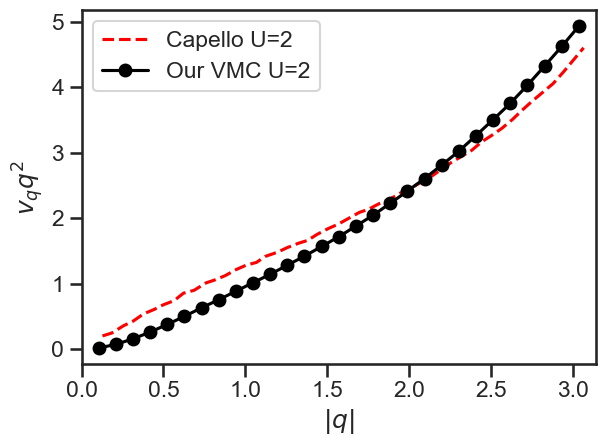

In [16]:
# -----------------------
# Load Capello data
# -----------------------

capello_q_U2, capello_vq_q2_U2 = load_capello_data(
    "../data/Capello_v_q_q_squared_vs_q_U_2_site_60.csv"
)

# -----------------------
# Load our VMC result
# -----------------------

vmc_q_U2, vmc_vq_U2, vmc_vq_q2_U2 = load_vmc_vq(
    "../data/C/1D/L60_N60/jastrow/VMC_vq_vs_q_U2.0.dat"
)

# -----------------------
# Plot
# -----------------------

fig, ax = plt.subplots()

plot_vq_comparison(ax,
                   vmc_q_U2, vmc_vq_q2_U2,
                   capello_q_U2, capello_vq_q2_U2,
                   U=2)

ax.set_xlim(0, np.pi)
ax.set_xlabel(r"$|q|$")
ax.set_ylabel(r"$v_q q^2$")
ax.legend()

plt.tight_layout()
plt.show()

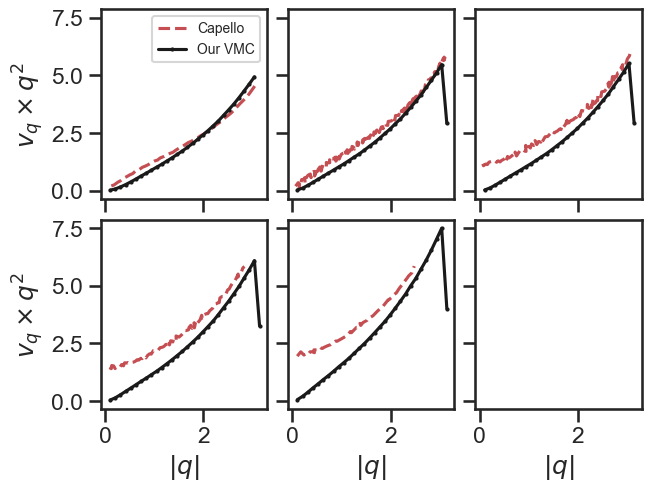

In [17]:
# VMC and Capello U = 2.0 60 sites data
Capello_q_U2, Capello_vq_q2_U2 = load_capello_data("../data/Capello_v_q_q_squared_vs_q_U_2_site_60.csv")
VMC_q_U2, VMC_vq_U2, VMC_vq__q2_U2 = load_vmc_vq("../data/C/1D/L60_N60/jastrow/VMC_vq_vs_q_U2.0.dat")

# VMC and Capello U = 2.4 60 sites data
Capello_q_U2_4, Capello_vq_q2_U2_4 = load_capello_data("../data/Capello_v_q_q_squared_vs_q_U_2.4_site_60.csv")
VMC_q_U2_4, VMC_vq_U2_4, VMC_vq__q2_U2_4 = load_vmc_vq("../data/C/1D/L60_N60/jastrow/VMC_vq_vs_q_U2.4.dat")

# VMC and Capello U = 2.5 60 sites data
Capello_q_U2_5, Capello_vq_q2_U2_5 = load_capello_data("../data/Capello_v_q_q_squared_vs_q_U_2.5_site_60.csv")
VMC_q_U2_5, VMC_vq_U2_5, VMC_vq__q2_U2_5 = load_vmc_vq("../data/C/1D/L60_N60/jastrow/VMC_vq_vs_q_U2.5.dat")\

# VMC and Capello U = 3.0 60 sites data
Capello_q_U3, Capello_vq_q2_U3 = load_capello_data("../data/Capello_v_q_q_squared_vs_q_U_3_site_60.csv")
VMC_q_U3, VMC_vq_U2, VMC_vq__q2_U3 = load_vmc_vq("../data/C/1D/L60_N60/jastrow/VMC_vq_vs_q_U3.0.dat")

# VMC and Capello U = 4.0 60 sites data
Capello_q_U4, Capello_vq_q2_U4 = load_capello_data("../data/Capello_v_q_q_squared_vs_q_U_4_site_60.csv")
VMC_q_U4, VMC_vq_U4, VMC_vq__q2_U4 = load_vmc_vq("../data/C/1D/L60_N60/jastrow/VMC_vq_vs_q_U4.0.dat")

# VMC and Capello U = 6.4 60 sites data
Capello_q_U6, Capello_vq_q2_U6 = load_capello_data("../data/Capello_v_q_q_squared_vs_q_U_6_site_60.csv")
# VMC_q_U6, VMC_vq_U6, VMC_vq__q2_U6 = load_vmc_vq("../data/C/1D/L60_N60/jastrow/VMC_vq_vs_q_U6.0.dat")


fig, ax = plt.subplots(2,3, sharex=True, sharey=True, constrained_layout=True)
ax[0][0].plot(Capello_q_U2, Capello_vq_q2_U2, c='r', linestyle='--', label="Capello")
ax[0][0].plot(VMC_q_U2, VMC_vq__q2_U2, marker='o', linestyle='-', c='k', label="Our VMC", markersize=2)
ax[0][1].plot(Capello_q_U2_4, Capello_vq_q2_U2_4, c='r', linestyle='--', label="Capello")
ax[0][1].plot(VMC_q_U2_4, VMC_vq__q2_U2_4, marker='o', linestyle='-', c='k', label="Our VMC", markersize=2)
ax[0][2].plot(Capello_q_U2_5, Capello_vq_q2_U2_5, c='r', linestyle='--', label="Capello")
ax[0][2].plot(VMC_q_U2_5, VMC_vq__q2_U2_5, marker='o', linestyle='-', c='k', label="Our VMC", markersize=2)
ax[1][0].plot(Capello_q_U3, Capello_vq_q2_U3, c='r', linestyle='--', label="Capello")
ax[1][0].plot(VMC_q_U3, VMC_vq__q2_U3, marker='o', linestyle='-', c='k', label="Our VMC", markersize=2)
ax[1][1].plot(Capello_q_U4, Capello_vq_q2_U4, c='r', linestyle='--', label="Capello")
ax[1][1].plot(VMC_q_U4, VMC_vq__q2_U4, marker='o', linestyle='-', c='k', label="Our VMC", markersize=2)
ax[1][0].set_xlabel(r"$|q|$")
ax[1][1].set_xlabel(r"$|q|$")
ax[1][2].set_xlabel(r"$|q|$")
ax[0][0].set_ylabel(r"$v_q \times q^2$")
ax[1][0].set_ylabel(r"$v_q \times q^2$")
# ax[0][0].set_xlim(0, np.pi)
ax[0][0].legend(loc="best", fontsize=10)
plt.savefig(r"./figures/Capello_comparison/60_particles_60_sites_comparison.pdf", dpi=600)
plt.show()

In [18]:
K = np.loadtxt(r"../data/QMC/1D_L8_N8/K_square_1D_8L_8N_PBC_4.000U_8.00beta_200bins1000_seed2001.dat")
V = np.loadtxt(r"../data/QMC/1D_L8_N8/V_square_1D_8L_8N_PBC_4.000U_8.00beta_200bins1000_seed2001.dat")

E = np.average(K + V)
K = np.average(K)
U = np.average(U)

In [19]:
E

-7.5285818749999995

In [20]:
K

-12.909521875000001

In [21]:
U

4.0